In [3]:
import os

import pandas as pd
import matplotlib.pyplot as plt 
import numpy as np
import xarray as xr
import geopandas as gpd
import seaborn as sns

from scipy import interpolate
from shapely.validation import make_valid
from shapely.geometry import Point
from mpl_toolkits.axes_grid1.axes_divider import make_axes_locatable
from matplotlib.lines import Line2D
from matplotlib.transforms import ScaledTranslation

os.unsetenv('PROJ_LIB')

plt.rcParams['legend.handlelength'] = 1
plt.rcParams['legend.handleheight'] = 1.125
plt.rcParams["font.family"]         = "Arial"

path_to_era5   = '/home/abhis/india_power/data/era5/'
path_to_data   = '/home/gterren/india_power/gridpath_india_viz/data/'
path_to_images = '/home/gterren/india_power/gridpath_india_viz/images/'

In [4]:
_bhutan = gpd.read_file(path_to_data + r"map/bhutan/bt.shp").to_crs("epsg:4326")
_india  = gpd.read_file(path_to_data + r"map/india/india-polygon.shp").to_crs("epsg:4326")

# Assuming your GeoDataFrame is named 'gdf' and the geometry column is 'geometry'
_india['geometry'] = _india['geometry'].apply(lambda geom: make_valid(geom) if geom else None)
_india = _india.dropna(subset = ['geometry'])  # Remove rows with None geometry

_nothern      = _india.loc[[4, 10, 11, 22, 24, 25, 30, 31, 35, 36]].dissolve().buffer(.025)#.to_crs(epsg=3395).to_crs("epsg:4326")
_northeastern = _india.loc[[1, 2, 18, 19, 20, 21, 29]].dissolve()
_western      = _india.loc[[5, 6, 7, 8, 9, 16, 17]].dissolve()
_southern     = _india.loc[[13, 14, 23, 27, 28, 34]].dissolve()
_eastern      = _india.loc[[3, 12, 26, 32, 33]].dissolve()
_regions      = pd.concat([_nothern, _northeastern, _western, _eastern], axis = 0)

ds_temp_ = xr.open_dataset(path_to_era5 + "India_2000-2020_era5_temp.nc", engine = "netcdf4")
#print(ds_temp_.max())
ds_wind_ = xr.open_dataset(path_to_era5 + "India_2000-2020_era5_wind100m.nc", engine = "netcdf4")
#print(ds_wind_)
ds_cloud_ = xr.open_dataset(path_to_era5 + "India_2000-2020_era5_cloud.nc", engine = "netcdf4")
#print(ds_cloud_)
ds_ghi_ = xr.open_dataset(path_to_era5 + "India_2000-2020_era5_ghi.nc", engine = "netcdf4")
print(ds_ghi_)

<xarray.Dataset>
Dimensions:     (valid_time: 175320, latitude: 110, longitude: 117)
Coordinates:
    number      int64 ...
  * valid_time  (valid_time) datetime64[ns] 2000-01-01 ... 2019-12-31T23:00:00
  * latitude    (latitude) float64 35.25 35.0 34.75 34.5 ... 8.75 8.5 8.25 8.0
  * longitude   (longitude) float64 68.25 68.5 68.75 69.0 ... 96.75 97.0 97.25
    expver      (valid_time) object ...
Data variables:
    ssrd        (valid_time, latitude, longitude) float32 ...
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2025-05-19T17:08 GRIB to CDM+CF via cfgrib-0.9.1...


/tmp/ipykernel_1262538/916490956.py:8: UserWarning: Geometry is in a geographic CRS. Results from 'buffer' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  _nothern      = _india.loc[[4, 10, 11, 22, 24, 25, 30, 31, 35, 36]].dissolve().buffer(.025)#.to_crs(epsg=3395).to_crs("epsg:4326")


In [ ]:
# Cyclone Titli: 16-21 (19) May 2020 - Touch land on 10th
#date = '2018-10-10T12:00:00' 

# 2019
# June 10: Delhi recorded an all-time high of 48°C.
# June 19: Churu in Rajasthan recorded 50.8°C, one of the highest ever recorded in India.

# Heatware: 9-15 (12) May 2002
date = '2019-06-12T10:00:00'

# # Dunkenflaut: 9-15 (12) May 2002
# date = '2018-02-07T06:00:00'

# Heatware: 9-15 (12) May 2002
date = '2013-03-25T09:00:00'
date = '2006-12-31T09:00:00'

# # Convert to pandas Series
# date = pd.Series(np.datetime64(date)).dt.tz_localize('Asia/Kolkata')
# #date = np.datetime64(date)#.dt.tz_localize('UTC')
# print(date)

# date = pd.to_datetime(date)
# print(date)

# Create a datetime64[ns] object from a string
# print(date.dt.tz_convert('UTC').to_numpy())
ds_w_ = ds_wind_.sel(valid_time = np.datetime64(date))['wnd100m'].to_numpy()*3.6
ds_t_ = ds_temp_.sel(valid_time = np.datetime64(date))['t2m'].to_numpy() - 273.15
ds_c_ = ds_cloud_.sel(valid_time = np.datetime64(date))['tcc'].to_numpy()*100
ds_g_ = ds_ghi_.sel(valid_time = np.datetime64(date))['ssrd'].to_numpy()/3600
print(ds_w_.shape, ds_t_.shape, ds_c_.shape, ds_g_.shape)

lat_ = ds_wind_['latitude'].to_numpy()
lon_ = ds_wind_['longitude'].to_numpy()
print(lat_.shape, lon_.shape)

(110, 117) (110, 117) (110, 117) (110, 117)
(110,) (117,)


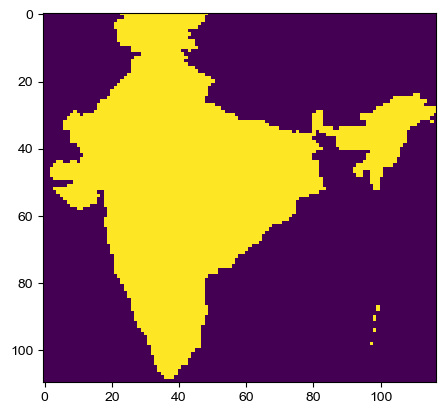

In [55]:
def is_within(point, polygon):
    return point.within(polygon)

_india_p = _india.dissolve()['geometry'].values[0]

X_, Y_ = np.meshgrid(lon_, lat_)
M_     = np.zeros(X_.shape, dtype = bool)

for i in range(X_.shape[0]):
    for j in range(Y_.shape[1]):
        M_[i, j] = is_within(Point(X_[i, j], Y_[i, j]), _india_p)

plt.figure()
plt.imshow(M_)
plt.show()

/tmp/ipykernel_1262538/2257802090.py:17: UserWarning: Geometry is in a geographic CRS. Results from 'buffer' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  _india.dissolve().buffer(.025).plot(ax        = _ax,


129.86667 822.36444


/tmp/ipykernel_1262538/2257802090.py:17: UserWarning: Geometry is in a geographic CRS. Results from 'buffer' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  _india.dissolve().buffer(.025).plot(ax        = _ax,


0.15047103 73.25134


/tmp/ipykernel_1262538/2257802090.py:17: UserWarning: Geometry is in a geographic CRS. Results from 'buffer' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  _india.dissolve().buffer(.025).plot(ax        = _ax,


0.0 100.0


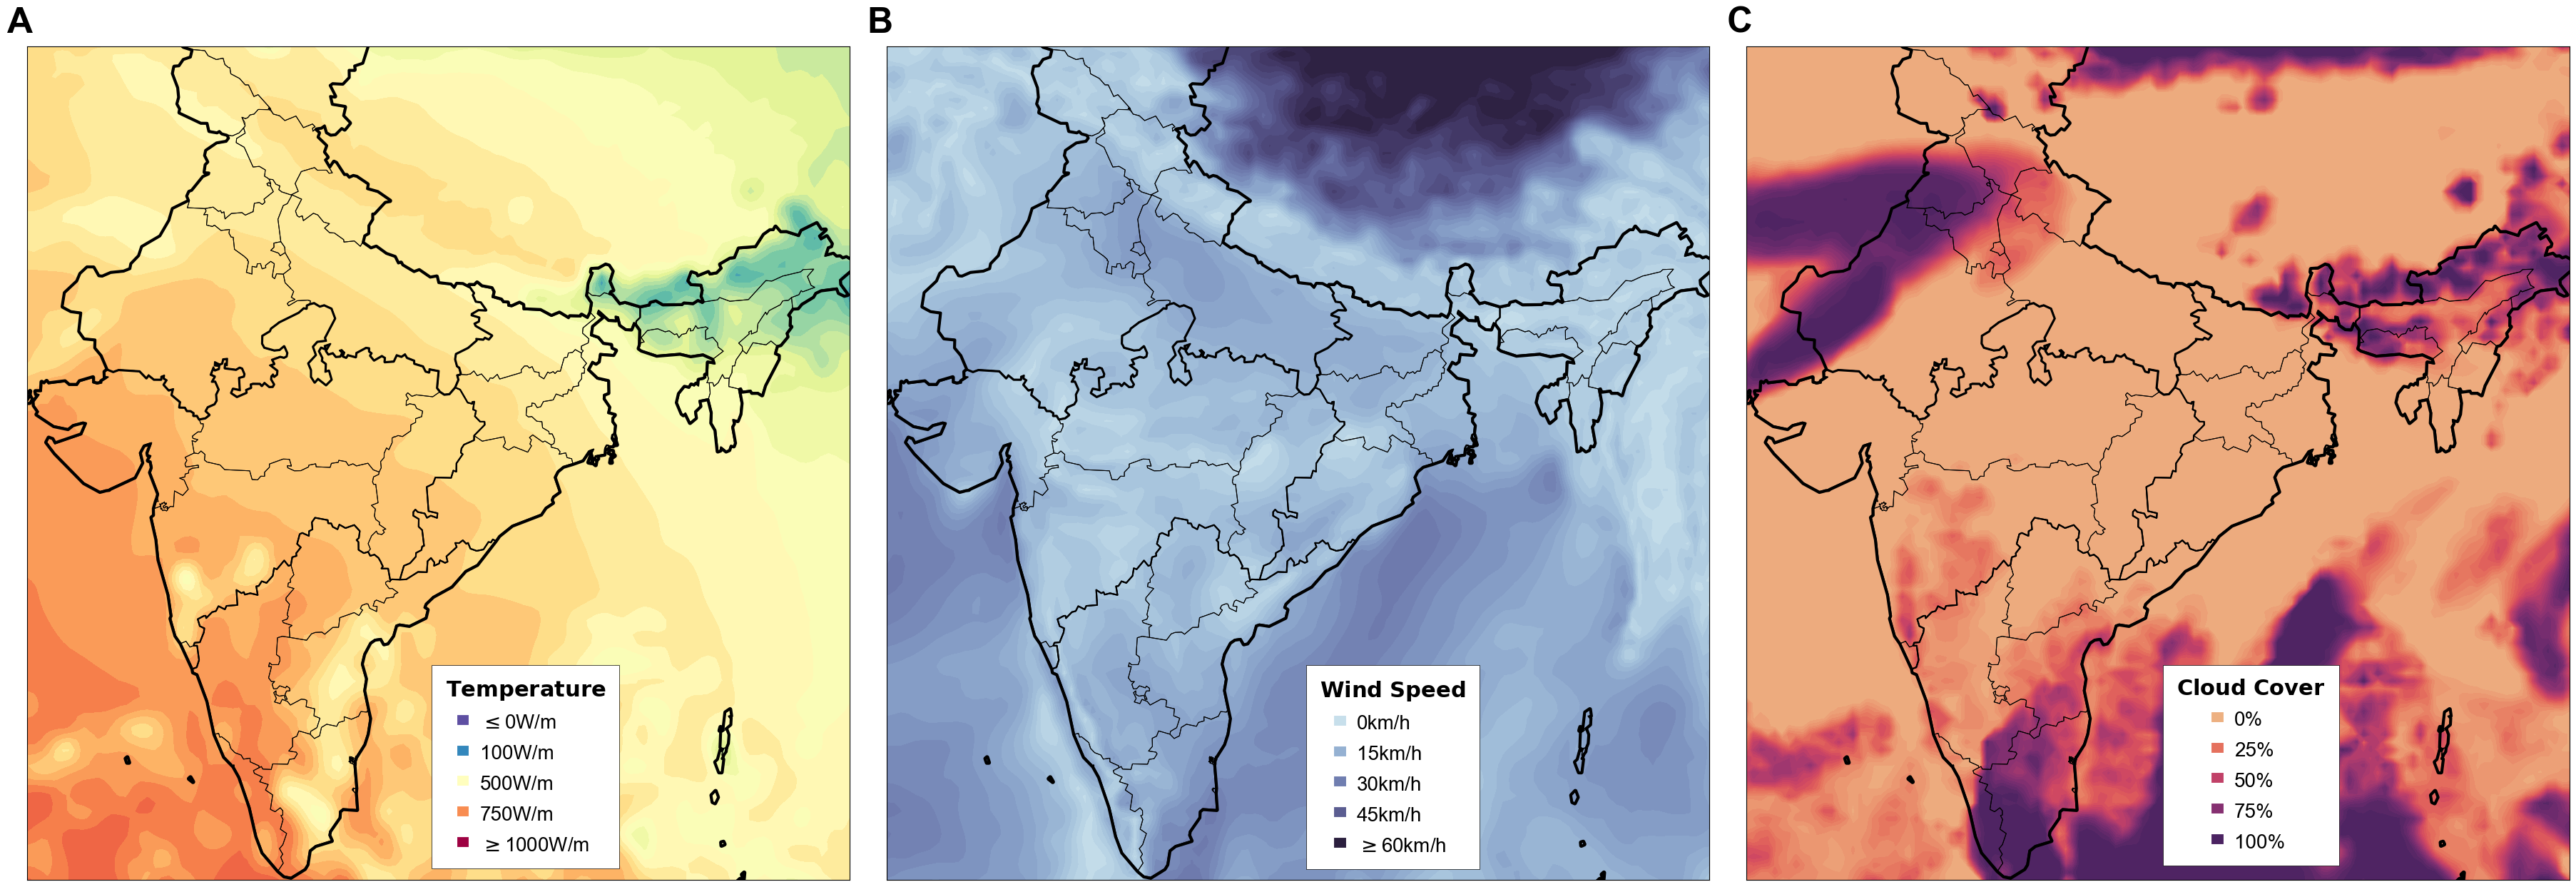

In [56]:
def _plot_weather_map(_ax, Z_, M_, legend_, legend_labels_, 
                      title = '', 
                      cmap  = 'Spectral_r'):


    _cmap = sns.color_palette(cmap, as_cmap = True)
    _norm = plt.Normalize(legend_[0], legend_[-1])

    _nothern.plot(ax = _ax, zorder = 9, color = 'None', lw = 1.5, edgecolor = 'k')
    _northeastern.plot(ax = _ax, zorder = 9, color = 'None', lw = 1.5, edgecolor = 'k')
    _western.plot(ax = _ax, zorder = 9, color = 'None', lw = 1.5, edgecolor = 'k')
    _southern.plot(ax = _ax, zorder = 9, color = 'None', lw =  1.5, edgecolor = 'k')
    _eastern.plot(ax = _ax, zorder = 9, color = 'None', lw = 1.5, edgecolor = 'k')
    # _bhutan.plot(ax = _ax, zorder = 8, color = 'lightgray', lw = 1.5, alpha = .5, edgecolor = 'white')
    _india.plot(ax = _ax, zorder = 8, color = 'None', lw = 0.75, edgecolor = 'k')

    _india.dissolve().buffer(.025).plot(ax        = _ax, 
                                        zorder    = 8, 
                                        color     = 'None', 
                                        lw        = 3., 
                                        edgecolor = 'k')

    X_, Y_ = np.meshgrid(lon_, lat_)
    print(Z_.min(), Z_.max())
    Z_p_ = Z_.copy()
    Z_p_[Z_p_ < legend_[0]]  = legend_[0]
    Z_p_[Z_p_ > legend_[-1]] = legend_[-1]
    #Z_p_[M_ == False] = np.nan
    cnt = _ax.contourf(X_, Y_, Z_p_, cmap   = _cmap, 
                                     norm   = _norm,
                                     zorder = 1,
                                     alpha  = 1.,
                                     levels = np.linspace(legend_[0], legend_[-1], 25))
        
    cnt.set_edgecolor("face")

    s0 = Line2D([], [], color = _cmap(_norm(legend_[0])), lw = 10)
    s1 = Line2D([], [], color = _cmap(_norm(legend_[1])), lw = 10)
    s2 = Line2D([], [], color = _cmap(_norm(legend_[2])), lw = 10)
    s3 = Line2D([], [], color = _cmap(_norm(legend_[3])), lw = 10)
    s4 = Line2D([], [], color = _cmap(_norm(legend_[4])), lw = 10)
    
    x_ = [s0, s1, s2, s3, s4]
    
    legend = _ax.legend(x_, legend_labels_, title          = title,
                                            title_fontsize = 22,
                                            handlelength   = .1,
                                            #borderpad        = 1.,
                                            ncol           = 1,
                                            bbox_to_anchor = (.725, .2625),
                                            frameon        = True,
                                            prop           = {'size': 20}, 
                                            edgecolor      = 'k', 
                                            facecolor      = 'white', 
                                            framealpha     = 1.)

    frame = legend.get_frame()
    frame.set_boxstyle('square')
    #legend._legend_box.align='left'
    frame.set_linewidth(0.5)

    _ax.axes.get_xaxis().set_ticks([])
    _ax.axes.get_yaxis().set_ticks([])

    _ax.set_xlim(lon_.min(), lon_.max())
    _ax.set_ylim(lat_.min(), lat_.max())

    #_ax.spines[['right', 'top', 'left', 'bottom']].set_visible(False)

fig, _ax = plt.subplot_mosaic([['A', 'B', 'C']], 
                              layout      = 'constrained', 
                              figsize     = (36, 15.75), 
                              gridspec_kw = {'width_ratios': [1, 1, 1]})

for label, ax in _ax.items():
    ax.text(0.0, 1.0, label, transform = (ax.transAxes + ScaledTranslation(-20/72, +7/72, fig.dpi_scale_trans)),
                             fontsize  = 36, 
                             weight    = "bold",
                             va        = 'bottom',
                             family    = 'Arial')

_plot_weather_map(_ax['A'], ds_g_, M_, legend_        = [0, 100, 500, 750, 1000], 
                                       #legend_        = [0, 12.5, 25, 37.5, 50],
                                       #legend_labels_ = ['$\leq$0°C', '10°C', '20°C', '30°C', '$\geq$40°C'], 
                                       legend_labels_ = ['$\leq$0W/m', '100W/m', '500W/m', '750W/m', '$\geq$1000W/m'], 
                                       cmap           = 'Spectral_r', 
                                       title          = '$\\bf{Temperature}$')

_plot_weather_map(_ax['B'], ds_w_, M_, legend_        = [0, 15, 30, 40, 60], 
                                       legend_labels_ = ['0km/h', '15km/h', '30km/h', '45km/h', '$\geq$60km/h'], 
                                       cmap           = "ch:s=.25,rot=-.25", 
                                       title          = '$\\bf{Wind \ Speed}$')

# _plot_weather_map(_ax['C'], ds_g_, M_, legend_        = [0, 250, 500, 750, 1000], 
#                                        legend_labels_ = ['0$W/m^2$', '250$W/m^2$', '500$W/m^2$', '750$W/m^2$', '$\geq$1000$W/m^2$'],
#                                        cmap           = 'flare', 
#                                        title          = '$\\bf{Solar \ Radiation}$')

_plot_weather_map(_ax['C'], ds_c_, M_, legend_        = [0, 25, 50, 75, 100], 
                                       legend_labels_ = ['0%', '25%', '50%', '75%', '100%'],
                                       cmap           = 'flare', 
                                       title          = '$\\bf{Cloud \ Cover}$')

plt.savefig(path_to_images + r'/weather_map-{}.pdf'.format(date), 
            bbox_inches = 'tight', 
            dpi         = 600)

plt.savefig(path_to_images + r'/weather_map-{}.png'.format(date), 
            bbox_inches = 'tight', 
            dpi         = 600)

plt.show()

findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not

findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not

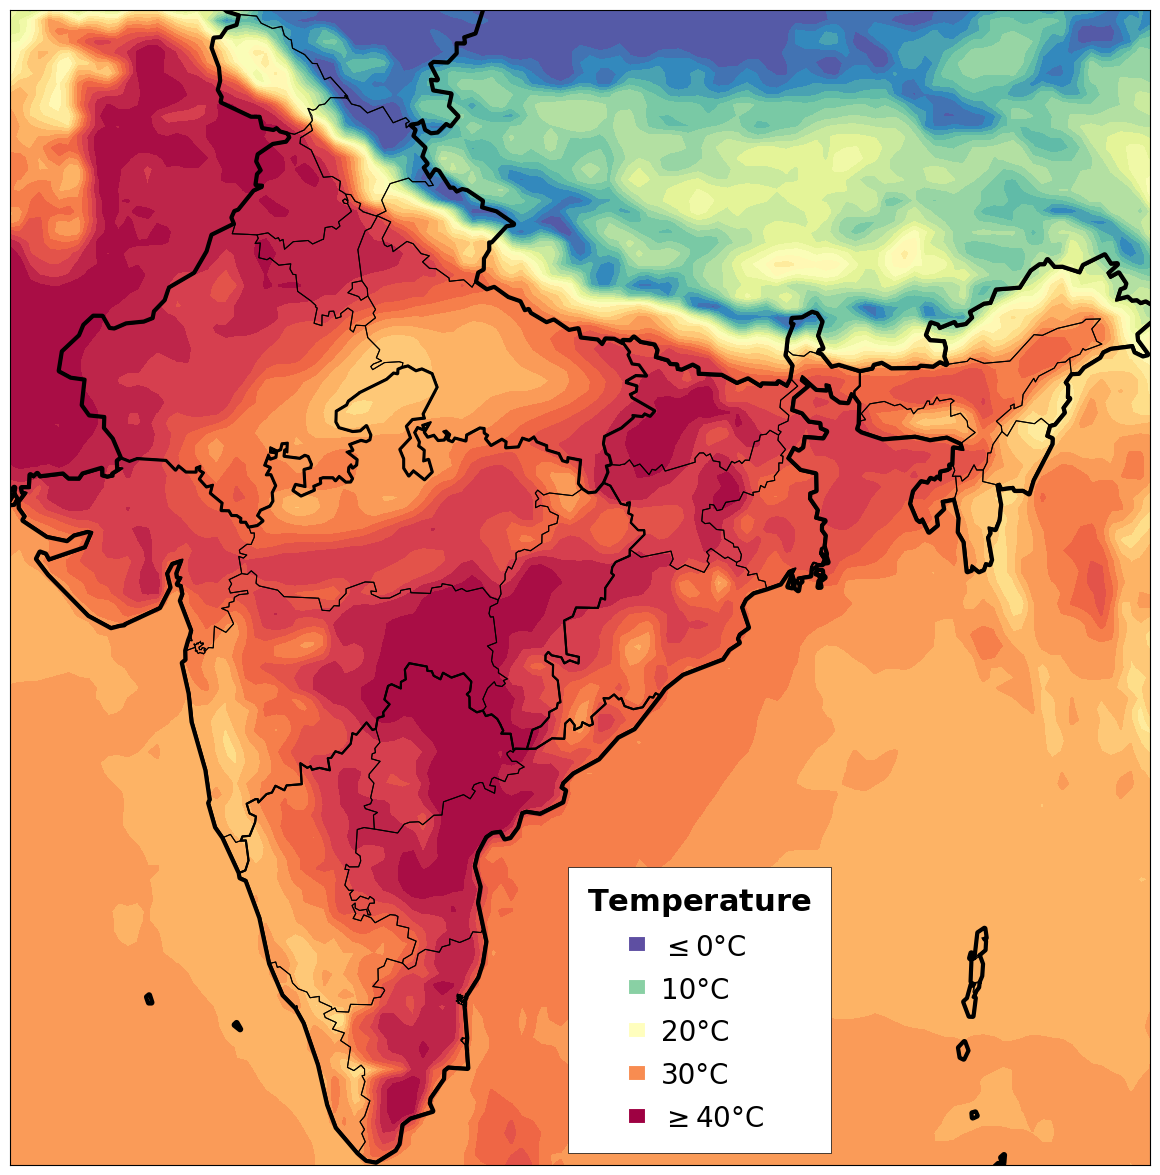

findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not

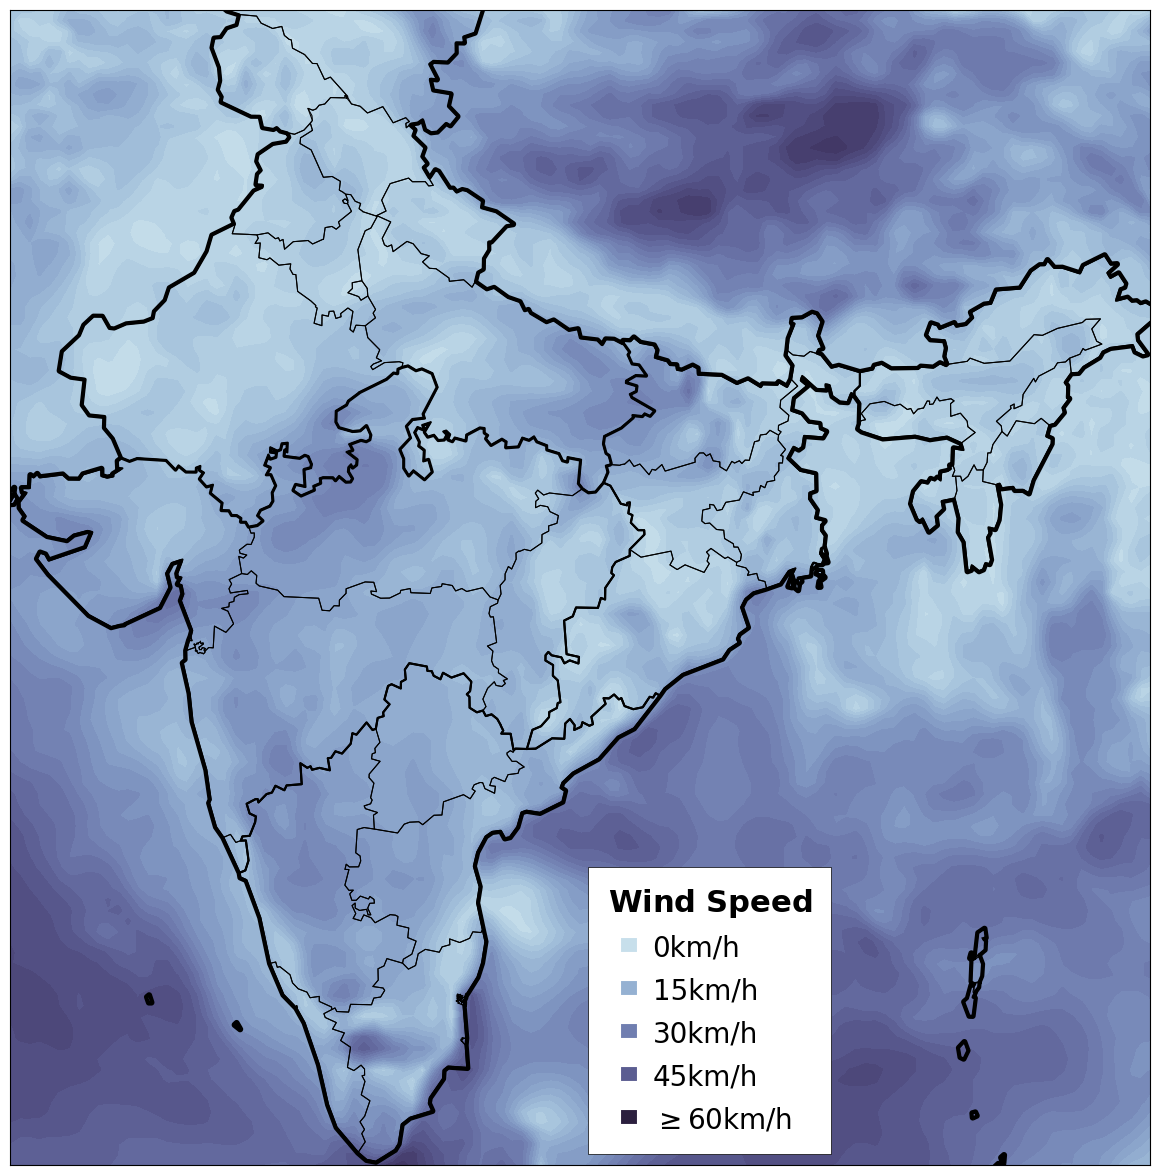

findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not

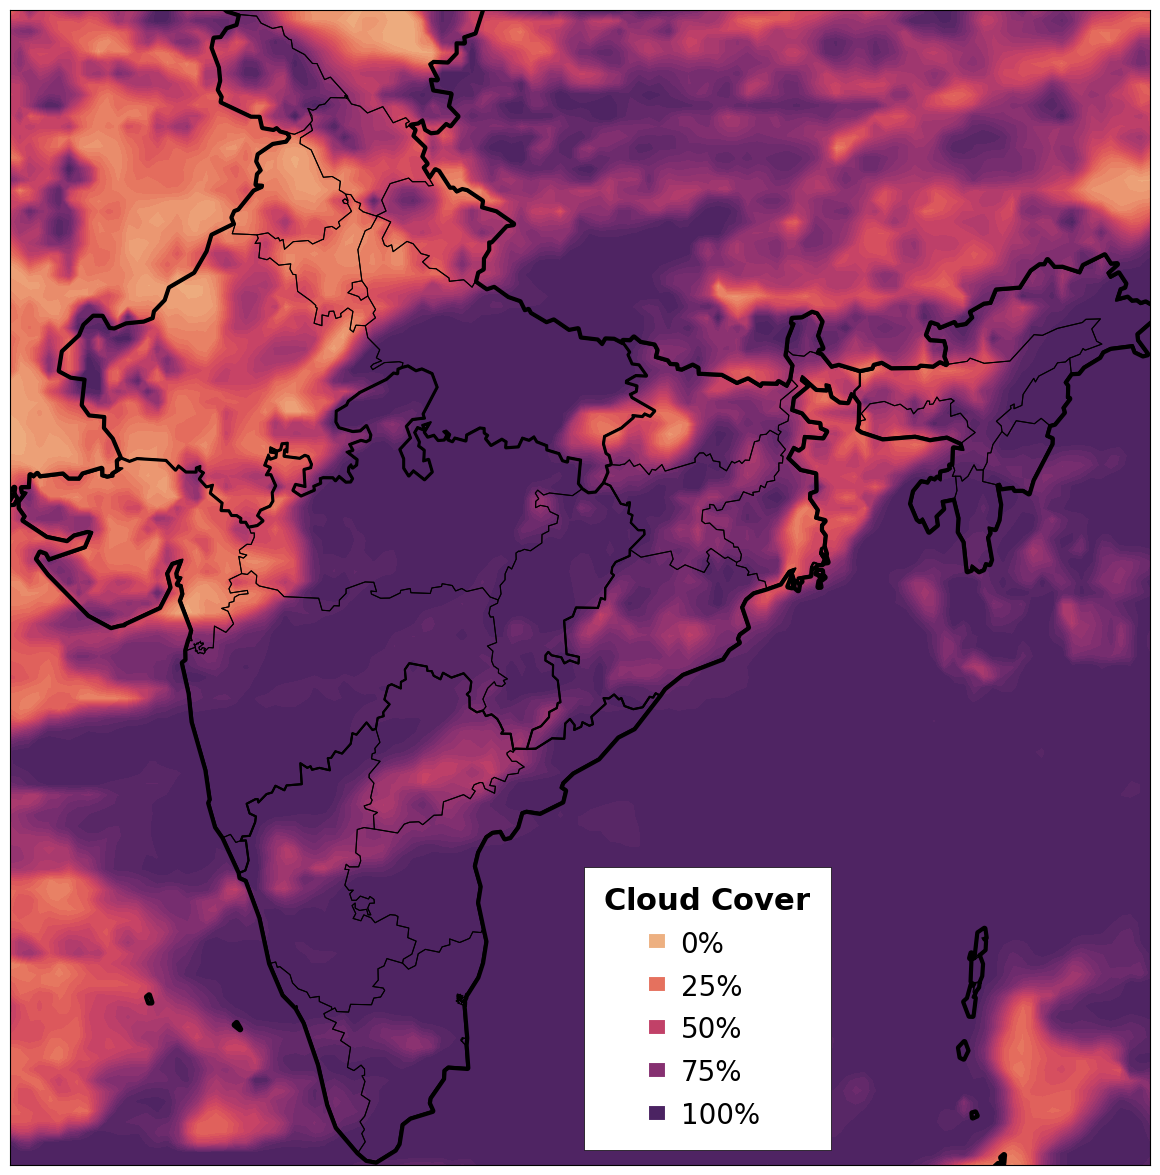

In [10]:
fig = plt.figure(figsize = (15, 15))
_ax = plt.subplot(111)

_plot_weather_map(_ax, ds_t_, M_, 
                  legend_        = [0, 10, 20, 30, 40], 
                  legend_labels_ = ['$\leq$0°C', '10°C', '20°C', '30°C', '$\geq$40°C'], 
                  cmap           = 'Spectral_r', 
                  title          = '$\\bf{Temperature}$')

plt.savefig(path_to_images + r'/temp_map-{}.pdf'.format(date), 
            bbox_inches = 'tight', 
            dpi         = 600)

plt.savefig(path_to_images + r'/temp_map-{}.png'.format(date), 
            bbox_inches = 'tight', 
            dpi         = 600)

plt.show()

fig = plt.figure(figsize = (15, 15))
_ax = plt.subplot(111)

_plot_weather_map(_ax, ds_w_, M_, 
                  legend_        = [0, 15, 30, 40, 60], 
                  legend_labels_ = ['0km/h', '15km/h', '30km/h', '45km/h', '$\geq$60km/h'], 
                  cmap           = "ch:s=.25,rot=-.25", 
                  title          = '$\\bf{Wind \ Speed}$')

plt.savefig(path_to_images + r'/wind_map-{}.pdf'.format(date), 
            bbox_inches = 'tight', 
            dpi         = 600)

plt.savefig(path_to_images + r'/wind_map-{}.png'.format(date), 
            bbox_inches = 'tight', 
            dpi         = 600)

plt.show()

fig = plt.figure(figsize = (15, 15))
_ax = plt.subplot(111)

_plot_weather_map(_ax, ds_c_, M_, 
                  legend_        = [0, 25, 50, 75, 100], 
                  legend_labels_ = ['0%', '25%', '50%', '75%', '100%'],
                  cmap           = 'flare', 
                  title          = '$\\bf{Cloud \ Cover}$')

plt.savefig(path_to_images + r'/cloud_map-{}.pdf'.format(date), 
            bbox_inches = 'tight', 
            dpi         = 600)

plt.savefig(path_to_images + r'/cloud_map-{}.png'.format(date), 
            bbox_inches = 'tight', 
            dpi         = 600)

plt.show()